In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import altair as alt
import scipy.stats as stats

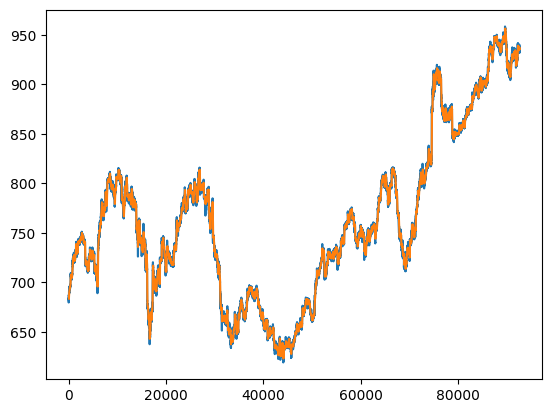

In [28]:
Axisbank=pd.read_csv("data/AXISBANK_minute.csv")
Axisbank.columns=Axisbank.columns.str.strip()
Day=Axisbank
Avg=Day['close'].rolling(window=60).mean()
plt.plot(np.linspace(0,len(Day),len(Day)),Day['close'])
plt.plot(np.linspace(0,len(Avg),len(Avg)),Avg)
plt.show()
Adani=pd.read_csv("data/ADANIENT_minute.csv")
Adani2=pd.read_csv("data/ADANIENT_minute_2.csv")
Adani2.columns=Adani2.columns.str.strip()
Axisbank2=pd.read_csv("data/AXISBANK_minute2.csv")
Axisbank2.columns=Axisbank2.columns.str.strip()
Bajaj2=pd.read_csv("data/BAJAJ-AUTO_minute_2.csv")
Bajaj2.columns=Bajaj2.columns.str.strip()

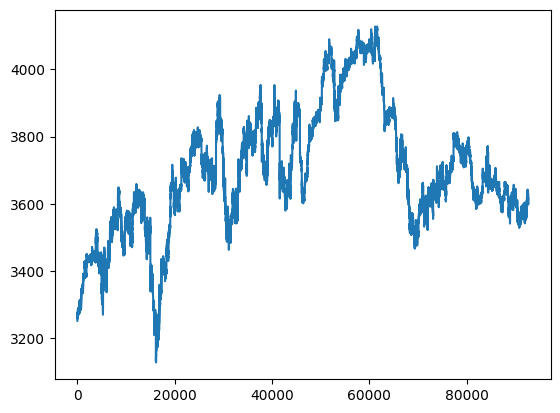

In [29]:
Bajaj=pd.read_csv("data/BAJAJ-AUTO_minute.csv")
plt.plot(np.linspace(0,len(Bajaj),len(Bajaj)),Bajaj['close'])
plt.show()

In [30]:
cost_per_side=0
def strat(data,e,Ts,Tl,sigmao,t):
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    df=T.dropna()

    ind_true = t * a
    ind_false = T * a + (t - T) * (e * a + (1 - e) * b)
    ind = np.where(T > t, ind_true, ind_false)
    
    
    # Generate the target signal direction (-1, 0, or 1)
    calculated_move = np.where(np.abs(ind) < 1e-2, 0, np.where(ind > 0, 1, -1))
    
    # 6. Periodic Execution Masking: ((x - Tl - 1) % t == 0 and x != Tl + 1)
    indices = np.arange(n)
    trade_mask = ((indices - Tl - 1) % t == 0) & (indices > Tl + 1)
    
    # HOLDING LOGIC: 
    # If it's a decision bar, take the calculated_move. 
    # If not, mark as np.nan so it inherits the previous position during forward-fill.
    moves = np.where(trade_mask, calculated_move, np.nan)
    
    # Convert to a Pandas Series to utilize optimized time-series filling methods
    Moves_Series = pd.Series(moves, index=Data.index)
    
    # ffill() carries the position forward for t bars. 
    # fillna(0) ensures the initialization period (before the first trade) is flat (0).
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 7. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    # Guard clause against empty arrays or zero volatility
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    marketreturn=np.exp(LogReturns.sum())-1
    stratreturn=np.exp(sum(loggain))-1
    print("Market returns at: "+str(marketreturn))
    print("Strategy return at : "+str(stratreturn))
    print("Sharpe : "+str(sharperatio))

    

In [31]:
cost_per_side=0
def Tseries(data,e,Ts,Tl,sigmao):
    Data = data.copy().reset_index(drop=True)
    
    Difs = Data['close'] - Data['close'].shift(1)
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    df=T.dropna()
    return(df)

In [32]:
times=Tseries(Bajaj,0.01,60,1200,0.1)

12.39973154457419


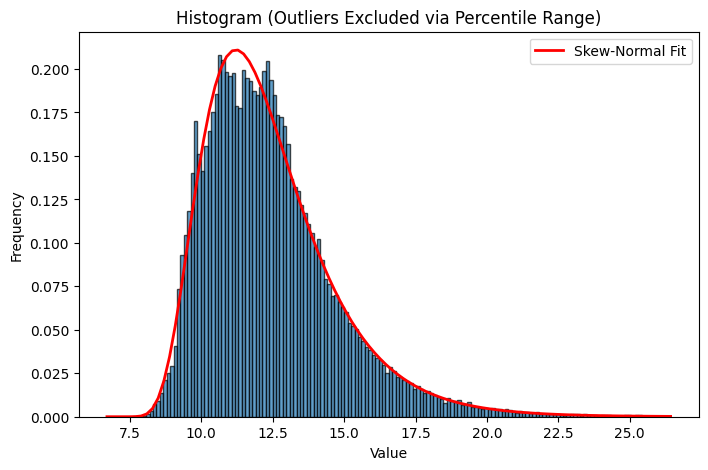

In [33]:
# 3. Plot using the 'range' parameter to truncate the view
data=times
lower_bound = np.percentile(data, 0)
upper_bound = np.percentile(data,100)
plt.figure(figsize=(8, 5))
print(np.log(data).mean())
plt.hist(np.log(data), bins=150, range=(np.log(lower_bound), np.log(upper_bound)), edgecolor='black', alpha=0.7,density=True)
a, b, loc, scale = stats.johnsonsu.fit(np.log(data))

# 3. Plot the theoretical PDF over your log histogram to see the match
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.johnsonsu.pdf(x,a,b,loc,scale)
plt.plot(x, p, 'r-', linewidth=2, label='Skew-Normal Fit')
plt.legend()
plt.title("Histogram (Outliers Excluded via Percentile Range)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [34]:
print(a,b,loc,scale)

-6.857354677059879 2.465429523974594 6.9572293499950995 0.6235157405280289


In [35]:
def Strat(data, e, Ts, Tl, sigmao, t):
    # 1. Create a clean copy and reset index to ensure perfect array alignment
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    # Branching paths for 'ind' depending on whether T > t
    ind_true = t * a
    ind_false = T * a + (t - T) * (e * a + (1 - e) * b)
    ind = np.where(T > t, ind_true, ind_false)
    
    # Generate the target signal direction (-1, 0, or 1)
    calculated_move =np.where(abs(ind)<1e-3,0,np.where(ind>0,1,-1))
    
    # 6. Periodic Execution Masking: ((x - Tl - 1) % t == 0 and x != Tl + 1)
    indices = np.arange(n)
    trade_mask = ((indices - Tl - 1) % t == 0) & (indices > Tl + 1)
    
    # HOLDING LOGIC: 
    # If it's a decision bar, take the calculated_move. 
    # If not, mark as np.nan so it inherits the previous position during forward-fill.
    moves = np.where(trade_mask, calculated_move, np.nan)
    
    # Convert to a Pandas Series to utilize optimized time-series filling methods
    Moves_Series = pd.Series(moves, index=Data.index)
    
    # ffill() carries the position forward for t bars. 
    # fillna(0) ensures the initialization period (before the first trade) is flat (0).
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 7. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    # Guard clause against empty arrays or zero volatility
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    
    return sharperatio

In [36]:
def visualise(data):
    arr=[]
    for x in range(100,10000):
        if(x%1000==0):
            print(x)
        arr.append(Strat(data,0.01,80,x,0.1,30))
    plt.figure(2)
    plt.hist(arr,density=True,bins=100)
    x=np.linspace(0,len(arr),len(arr))
    plt.figure()
    plt.scatter(x,arr,s=0.5,c=(x+100)%30,cmap="viridis")
    w=100
    plt.axhline(1.8,c="green")
    plt.colorbar()
    plt.show()

1000
2000
3000
4000
5000
6000
7000
8000
9000


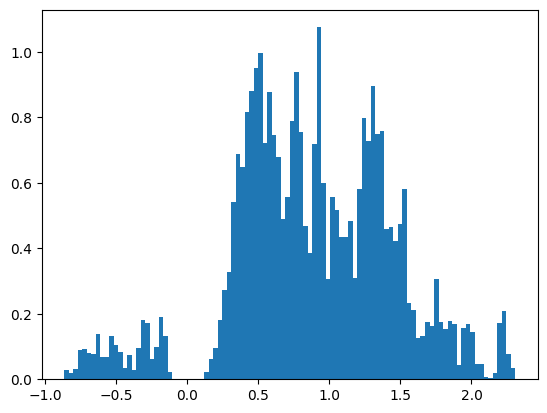

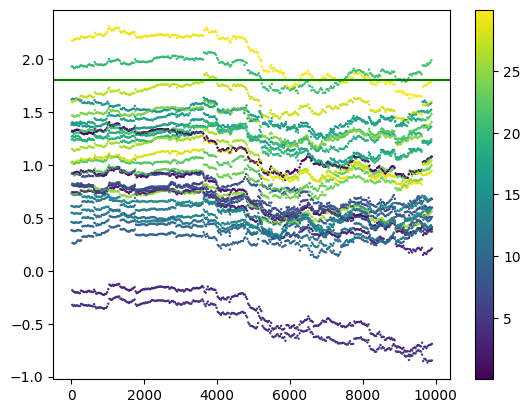

In [37]:
visualise(Bajaj)

1000
2000
3000
4000
5000
6000
7000
8000
9000


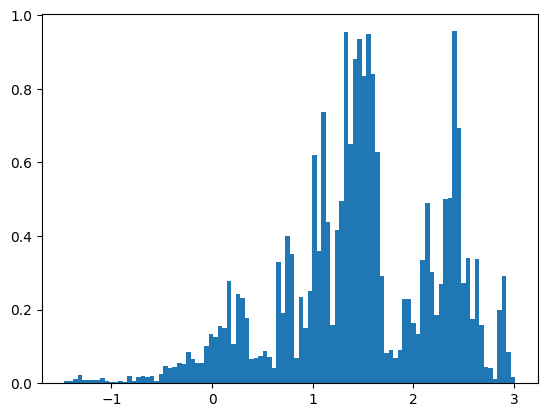

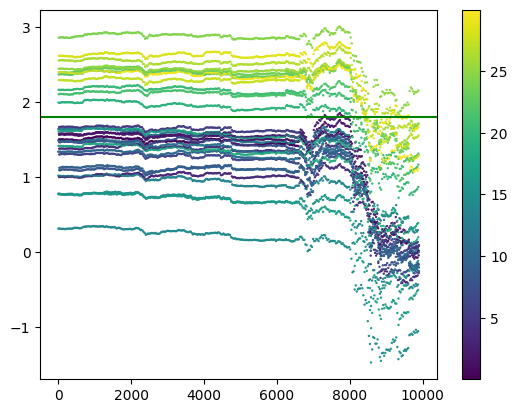

In [38]:
visualise(Adani2)

1000
2000
3000
4000
5000
6000
7000
8000
9000


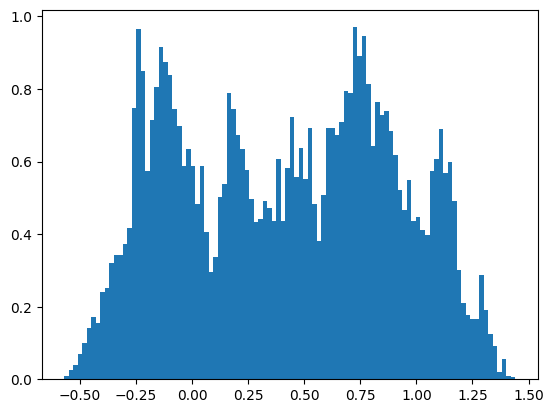

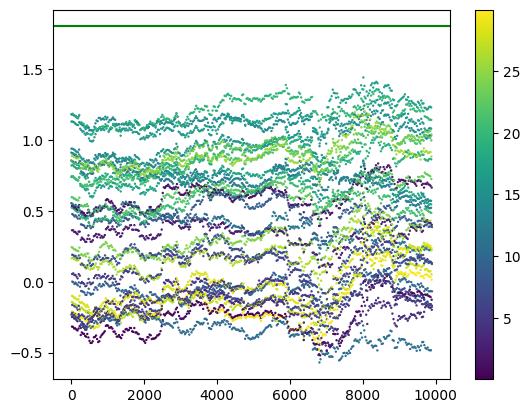

In [39]:
visualise(Axisbank2)

In [40]:
def Strat_Ensemble_Vectorized(data, Tl,ind,e=0.01, Ts=80, sigmao=0.1, t=30):
    # 1. Create a clean copy and reset index to ensure perfect array alignment
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences exactly as in your code
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    
    # 3. Calculate global volatility metric matching your setup exactly
    sigma_series = Difs.dropna().expanding().std()
    sigma = sigma_series.reindex(Data.index).values  # Align index back to Data
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Difs_shifted = Difs.shift(1)
    
    # Calculate Small (Ts=80) using standard pandas rolling
    Small = Difs_shifted.rolling(window=Ts).mean().values
    
    # --- LOOP-FREE LOOKBACK SUM ENGINE ---
    # Create an array of our target Tl windows ranging from 115 to 130 inclusive (131 is upper bound exclusive)
    tl_range = np.arange(Tl+15+(Tl-100)%30, Tl+31+(Tl-100)%30)  # Length: 16 elements
    
    # Generate 1D cumulative sum to extract any arbitrary rolling window sum instantly
    Difs_raw = Difs_shifted.fillna(0).values
    cusum = np.zeros(n + 1)
    np.cumsum(Difs_raw, out=cusum[1:])
    
    # Broadcast subtraction across indices and lookback windows
    idx_end = np.arange(1, n + 1)[:, None]          # Shape: (n, 1)
    idx_start = idx_end - tl_range[None, :]         # Shape: (n, 16)
    idx_start_clipped = np.maximum(0, idx_start)
    
    # Compute the rolling sums matrix and divide by window sizes to get Long means
    rolling_sums_matrix = cusum[idx_end] - cusum[idx_start_clipped]
    Long_matrix = rolling_sums_matrix / tl_range[None, :]  # Shape: (n, 16)
    
    # Pad incomplete early windows with NaN to match pandas behavior perfectly
    Long_matrix[idx_start < 0] = np.nan
    # -------------------------------------

    # 5. Execute mathematical equations simultaneously across 2D matrix blocks
    # Broadcast 1D variables (n,) into 2D spaces (n, 16)
    a_mat = (Small / (1 + rho / Ts))[:, None]
    b_mat = Long_matrix / (1 + rho[:, None] / tl_range[None, :])
    
    denominator = ((a_mat - b_mat) ** 2) + 1e-9
    
    # Compute T matrix
    sigma_sq = (sigma * sigma)[:, None]
    T_mat = (-1 * np.log(e) * 2 * sigma_sq) / denominator

    # --- DECAYING WEIGHTED SUM OVER MULTIPLE FORWARD HORIZONS (t) ---
    # Create containers to accumulate blended movements and weights across all horizons
    blended_move_accum = np.zeros(n)
    total_weight_mass = 0.0
    
    # Generate the forward look-ahead horizon space
    t_horizons = np.arange(1, t + 1)
    
    for t_horizon in t_horizons:
        # Branching paths for 'ind' matrix depending on whether T_mat > t_horizon
        ind_true = t_horizon * a_mat
        ind_false = T_mat * a_mat + (t_horizon - T_mat) * (e * a_mat + (1 - e) * b_mat)
        ind_matrix_t = np.where(T_mat > t_horizon, ind_true, ind_false)
        
        # Generate individual target signals directions matrix for this specific horizon
        calculated_move_matrix_t = np.where(abs(ind_matrix_t) < 1e-3, 0, np.where(ind_matrix_t > 0, 1, -1))
        
        # 6. Apply Softmax blending across the window axis (axis 1)
        max_ind_t = np.nanmax(ind_matrix_t, axis=1, keepdims=True)
        exp_ind_t = np.exp(ind_matrix_t - max_ind_t)
        exp_ind_t = np.nan_to_num(exp_ind_t, nan=0.0)
        softmax_weights_t = exp_ind_t / (np.sum(exp_ind_t, axis=1, keepdims=True) + 1e-15)
        
        # Take the weighted sum of moves across the 16 lookback options for this horizon
        blended_move_t = np.sum(softmax_weights_t * calculated_move_matrix_t, axis=1)  # Shape: (n,)
        
        # Compute the exponential decay factor relative to the lookback max parameter stride
        decay_weight = np.exp(-t_horizon / t)
        
        # Accumulate the weighted results
        blended_move_accum += blended_move_t * decay_weight
        total_weight_mass += decay_weight
        
    # Standardize the aggregated signal across the entire forward matrix spectrum
    blended_move = blended_move_accum / total_weight_mass
    # -----------------------------------------------------------------
    
    # 7. Periodic Execution Masking using the maximum window cutoff (130)
    max_Tl = 130
    indices = np.arange(n)
    trade_mask = ((indices - max_Tl - 1) % t == 0) & (indices > max_Tl + 1)
    
    # Apply trade masking and execute holding forward-fill logic
    moves = np.where(trade_mask, blended_move, np.nan)
    Moves_Series = pd.Series(moves, index=Data.index)
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 8. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    marketreturn = np.exp(LogReturns.sum()) - 1
    stratreturn = np.exp(sum(loggain)) - 1
    if(ind==0):
        print("Market returns at: " + str(marketreturn))
        print("Strategy return at : " + str(stratreturn))
        print("Sharpe : " + str(sharperatio))
    return sharperatio

In [41]:
def visualise_new(data):
    arr=[]
    for x in range(100,500):
        print(x)
        arr.append(Strat_Ensemble_Vectorized(data,x,1))
    plt.figure(2)
    plt.hist(arr,density=True,bins=100)
    x=np.linspace(0,len(arr),len(arr))
    plt.figure()
    plt.scatter(x,arr,s=0.5,c=(x+100)%30,cmap="viridis")
    w=100
    plt.axhline(0,c="green")
    plt.colorbar()
    plt.show()

100


/tmp/ipykernel_6149/531641535.py:72: RuntimeWarning: All-NaN slice encountered
  max_ind_t = np.nanmax(ind_matrix_t, axis=1, keepdims=True)


101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350


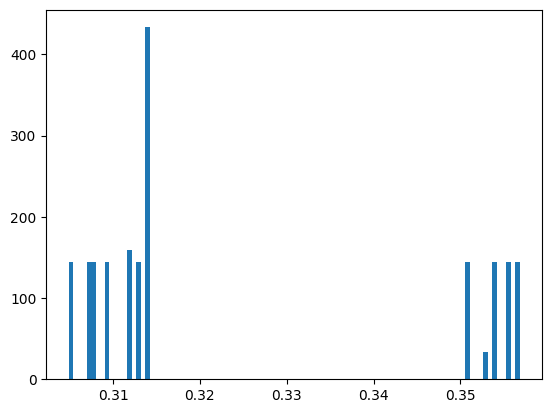

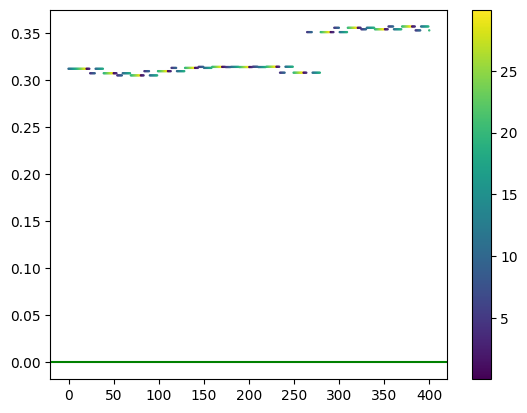

In [42]:
visualise_new(Bajaj)